# Khám phá dữ liệu chất lượng không khí Hoàn Kiếm (2022–2025)

Notebook này giữ các trực quan quan trọng cho báo cáo EDA: chất lượng dữ liệu, cơ sở chọn PM2.5, phân phối PM2.5, tính mùa vụ và mối liên hệ với thời tiết.

> Lưu ý: tương quan chỉ phản ánh **mối liên hệ**, không đủ để kết luận quan hệ nhân quả.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.labelsize": 11, "axes.titleweight": "bold",
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.unicode_minus": False
})

def find_project_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "data2225.csv").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy thư mục dự án chứa data/raw/data2225.csv")

PROJECT_ROOT = find_project_root(Path.cwd())

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "data2225.csv"
CLEAN_PATH = PROJECT_ROOT / "data" / "processed" / "data2225_done.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def save_report_figure(fig, filename):
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Đã lưu hình: {output_path}")
    return output_path
pollutant_cols = ["CO", "NO2", "O3", "PM10", "PM25", "SO2"]
weather_cols = ["Clouds", "Precipitation", "Pressure", "Relative Humidity", "Temperature", "UV Index", "Wind Speed"]
numeric_cols = ["AQI"] + pollutant_cols + weather_cols
display_names = {
    "PM25": "PM2.5", "PM10": "PM10", "CO": "CO", "NO2": "NO₂",
    "O3": "O₃", "SO2": "SO₂", "AQI": "AQI",
    "Clouds": "Độ che phủ mây", "Precipitation": "Lượng mưa",
    "Pressure": "Áp suất", "Relative Humidity": "Độ ẩm tương đối",
    "Temperature": "Nhiệt độ", "UV Index": "Chỉ số UV",
    "Wind Speed": "Tốc độ gió"
}
weather_units = {
    "Clouds": "%", "Precipitation": "mm", "Pressure": "hPa",
    "Relative Humidity": "%", "Temperature": "°C",
    "UV Index": "", "Wind Speed": "m/s"
}

df_raw = pd.read_csv(RAW_PATH)
df_clean = pd.read_csv(CLEAN_PATH)
required_raw = {"Local Time", "AQI", *pollutant_cols, *weather_cols}
required_clean = {"Local Time", "PM25", "IsHoliday", *weather_cols}
missing_raw_cols = sorted(required_raw.difference(df_raw.columns))
missing_clean_cols = sorted(required_clean.difference(df_clean.columns))
if missing_raw_cols or missing_clean_cols:
    raise ValueError(f"Thiếu cột dữ liệu — raw: {missing_raw_cols}; clean: {missing_clean_cols}")

for name, frame in (("raw", df_raw), ("clean", df_clean)):
    frame["Local Time"] = pd.to_datetime(frame["Local Time"], errors="coerce")
    invalid_time_count = int(frame["Local Time"].isna().sum())
    if invalid_time_count:
        raise ValueError(f"Dữ liệu {name} có {invalid_time_count} timestamp không hợp lệ")
    frame.sort_values("Local Time", inplace=True)
for col in numeric_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

overview = pd.DataFrame({
    "Chỉ tiêu": ["Số bản ghi gốc", "Số thuộc tính gốc", "Thời điểm bắt đầu", "Thời điểm kết thúc", "Bản ghi trùng hoàn toàn", "Timestamp trùng"],
    "Giá trị": [f"{len(df_raw):,}", len(df_raw.columns), df_raw["Local Time"].min(), df_raw["Local Time"].max(), int(df_raw.duplicated().sum()), int(df_raw["Local Time"].duplicated().sum())]
})
display(overview)
display(pd.DataFrame({"Kiểu dữ liệu": df_raw.dtypes.astype(str)}))

,Chỉ tiêu,Giá trị
0,Số bản ghi gốc,"34,759"
1,Số thuộc tính gốc,19
2,Thời điểm bắt đầu,2022-01-13 07:00:00
3,Thời điểm kết thúc,2025-12-31 23:00:00
4,Bản ghi trùng hoàn toàn,0
5,Timestamp trùng,8


,Kiểu dữ liệu
Local Time,datetime64[ns]
UTC Time,object
City,object
Country Code,object
Timezone,object
AQI,int64
CO,float64
NO2,float64
O3,float64
PM10,float64


## 1. Chất lượng và tính liên tục của dữ liệu

Biểu đồ bên trái cho biết tỷ lệ thiếu theo biến; biểu đồ bên phải cho biết mức đầy đủ của timestamp theo tháng. Số bản ghi trùng đã được trình bày bằng chỉ tiêu, không cần biểu đồ riêng.

,Số giá trị thiếu,Tỷ lệ thiếu (%)
CO,74,0.21
NO2,74,0.21
O3,74,0.21
SO2,74,0.21
PM10,2,0.01
PM25,2,0.01


Số mốc giờ bị thiếu: 18
Mức đầy đủ toàn kỳ: 99.95%


Đã lưu hình: E:\Document\hoankiem-air-quality-forecasting\reports\figures\hinh_4_1_chat_luong_du_lieu.png


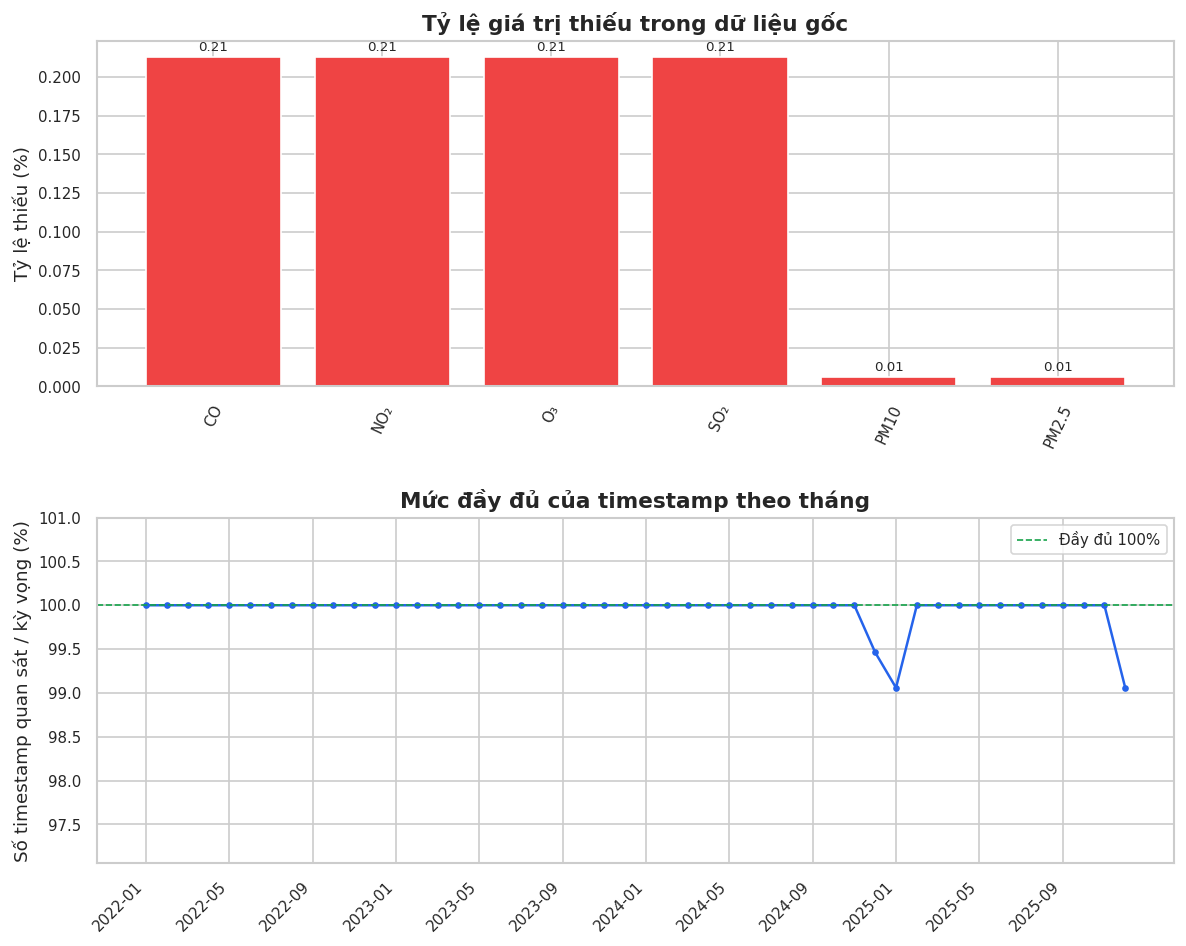

In [2]:
analysis_cols = [col for col in numeric_cols if col in df_raw.columns]
missing_count = df_raw[analysis_cols].isna().sum()
missing_pct = (missing_count / len(df_raw) * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({"Số giá trị thiếu": missing_count, "Tỷ lệ thiếu (%)": missing_count / len(df_raw) * 100})
missing_summary = missing_summary.loc[missing_summary["Số giá trị thiếu"] > 0].sort_values("Số giá trị thiếu", ascending=False)
missing_to_plot = missing_pct[missing_pct > 0]
display(missing_summary.round(2))
timestamps = df_raw["Local Time"].dropna().drop_duplicates().sort_values()
periods = pd.period_range(timestamps.min().to_period("M"), timestamps.max().to_period("M"), freq="M")
observed = timestamps.groupby(timestamps.dt.to_period("M")).size().reindex(periods, fill_value=0)
expected = []
for period in periods:
    start = max(period.start_time, timestamps.min().floor("h"))
    end = min(period.end_time.floor("h"), timestamps.max().floor("h"))
    expected.append(max(0, int((end - start) / pd.Timedelta(hours=1)) + 1))
coverage = pd.DataFrame({"Quan sát": observed.to_numpy(), "Kỳ vọng": expected}, index=periods.astype(str))
coverage["Đầy đủ (%)"] = coverage["Quan sát"] / coverage["Kỳ vọng"] * 100
full_hourly_index = pd.date_range(timestamps.min(), timestamps.max(), freq="h")
missing_hours = full_hourly_index.difference(pd.DatetimeIndex(timestamps))
print(f"Số mốc giờ bị thiếu: {len(missing_hours):,}")
print(f"Mức đầy đủ toàn kỳ: {len(timestamps) / len(full_hourly_index) * 100:.2f}%")

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
missing_labels = [display_names.get(col, col) for col in missing_to_plot.index]
bars = axes[0].bar(missing_labels, missing_to_plot.values, color="#ef4444")
axes[0].set_title("Tỷ lệ giá trị thiếu trong dữ liệu gốc")
axes[0].set_ylabel("Tỷ lệ thiếu (%)")
axes[0].tick_params(axis="x", rotation=65)
axes[0].bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

x = np.arange(len(coverage))
axes[1].plot(x, coverage["Đầy đủ (%)"], marker="o", markersize=3, color="#2563eb")
axes[1].axhline(100, color="#16a34a", linestyle="--", linewidth=1, label="Đầy đủ 100%")
tick_step = max(1, len(coverage) // 12)
axes[1].set_xticks(x[::tick_step], coverage.index[::tick_step], rotation=45, ha="right")
axes[1].set_ylim(max(0, coverage["Đầy đủ (%)"].min() - 2), 101)
axes[1].set_title("Mức đầy đủ của timestamp theo tháng")
axes[1].set_ylabel("Số timestamp quan sát / kỳ vọng (%)")
axes[1].legend()
fig.tight_layout(h_pad=2.2)
save_report_figure(fig, "hinh_4_1_chat_luong_du_lieu.png")
plt.show()

## 2. Cơ sở lựa chọn PM2.5 làm biến mục tiêu

Biểu đồ so sánh mức độ liên hệ giữa các chất ô nhiễm và AQI. PM2.5 được tô nổi bật. Vì AQI được xây dựng từ các chất ô nhiễm, đây chỉ là bằng chứng mô tả; lập luận lựa chọn còn cần kết hợp ý nghĩa sức khỏe, độ đầy đủ dữ liệu và mục tiêu dự báo.

Đã lưu hình: E:\Document\hoankiem-air-quality-forecasting\reports\figures\hinh_4_2_ly_do_chon_pm25.png


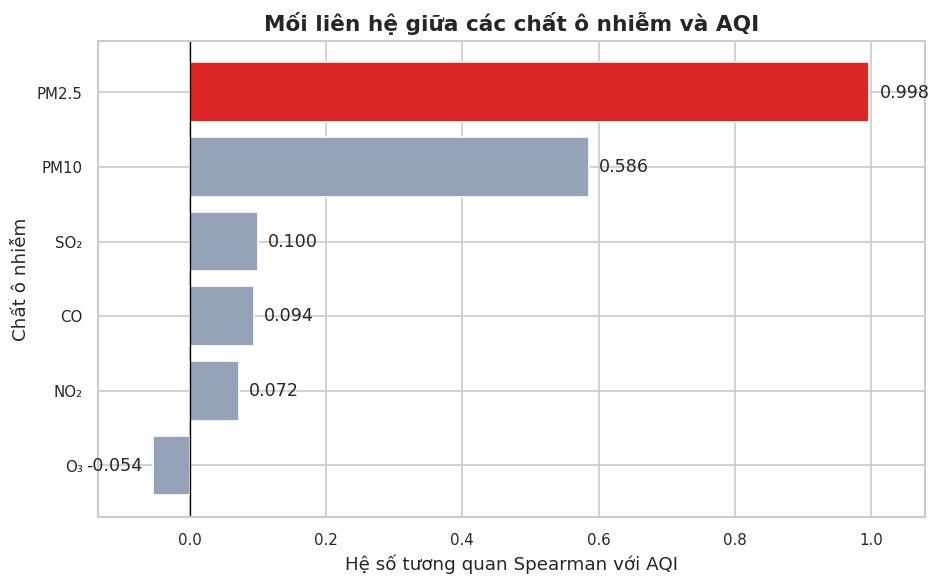

In [3]:
aqi_corr = df_raw[["AQI"] + pollutant_cols].corr(method="spearman")["AQI"].drop("AQI").sort_values()
pollutant_labels = [display_names.get(col, col) for col in aqi_corr.index]
colors = ["#dc2626" if col == "PM25" else "#94a3b8" for col in aqi_corr.index]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(pollutant_labels, aqi_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(min(-0.12, aqi_corr.min() - 0.08), 1.08)
ax.set_xlabel("Hệ số tương quan Spearman với AQI")
ax.set_ylabel("Chất ô nhiễm")
ax.set_title("Mối liên hệ giữa các chất ô nhiễm và AQI")
for bar, value in zip(bars, aqi_corr.values):
    offset = 0.015 if value >= 0 else -0.015
    ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", ha="left" if value >= 0 else "right")
fig.tight_layout()
save_report_figure(fig, "hinh_4_2_ly_do_chon_pm25.png")
plt.show()

## 3. Phân phối và phạm vi biến động của PM2.5

Histogram mô tả dạng phân phối; boxplot thể hiện trung vị, khoảng biến động và các điểm cực trị. Các điểm xa chưa mặc nhiên là lỗi vì chúng có thể là đợt ô nhiễm thực tế.

,PM2.5
count,34759.000000
mean,21.136580
std,17.542311
min,0.480000
25%,9.900000
50%,16.500000
75%,26.000000
90%,40.500000
95%,54.600000
99%,91.200000


Độ lệch (skewness): 2.69


Đã lưu hình: E:\Document\hoankiem-air-quality-forecasting\reports\figures\hinh_4_3_phan_phoi_pm25.png


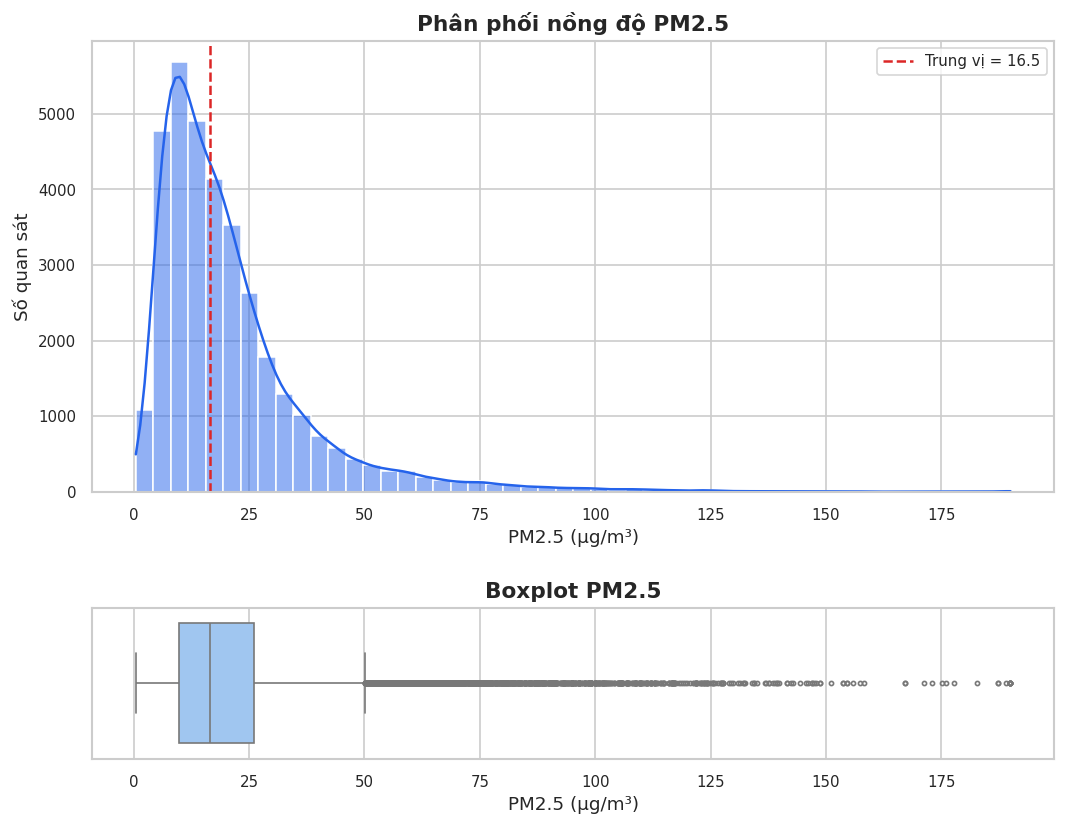

In [4]:
pm25 = df_clean["PM25"].dropna()
display(pm25.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("PM2.5"))
print(f"Độ lệch (skewness): {pm25.skew():.2f}")
fig, axes = plt.subplots(2, 1, figsize=(9, 7), gridspec_kw={"height_ratios": [3, 1]})
sns.histplot(pm25, bins=50, kde=True, color="#2563eb", ax=axes[0])
axes[0].axvline(pm25.median(), color="#dc2626", linestyle="--", label=f"Trung vị = {pm25.median():.1f}")
axes[0].set_title("Phân phối nồng độ PM2.5")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Số quan sát")
axes[0].legend()
sns.boxplot(x=pm25, color="#93c5fd", ax=axes[1], fliersize=2.5)
axes[1].set_title("Boxplot PM2.5")
axes[1].set_xlabel("PM2.5 (µg/m³)")
axes[1].set_ylabel("")
fig.tight_layout(h_pad=2.0)
save_report_figure(fig, "hinh_4_3_phan_phoi_pm25.png")
plt.show()

## 4. Xu hướng và tính mùa vụ của PM2.5

Đường trung bình ngày và trung bình trượt 7 ngày làm rõ xu hướng. Heatmap tháng × giờ thể hiện đồng thời mùa vụ trong năm và chu kỳ trong ngày.

Đã lưu hình: E:\Document\hoankiem-air-quality-forecasting\reports\figures\hinh_4_4_xu_huong_mua_vu_pm25.png


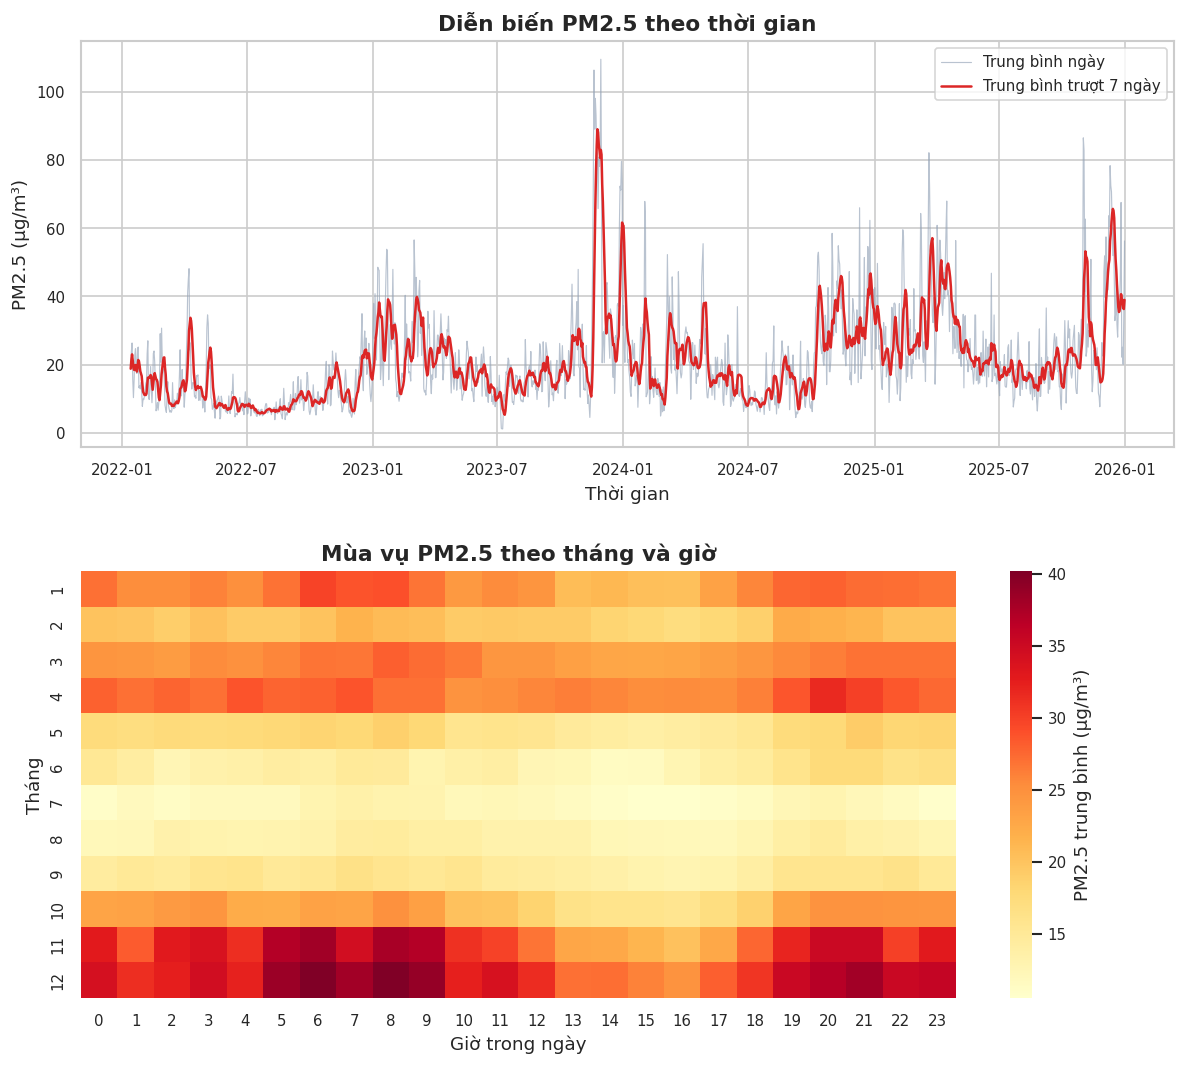

In [5]:
pm_time = df_clean[["Local Time", "PM25"]].dropna(subset=["Local Time"]).sort_values("Local Time").set_index("Local Time")["PM25"]
daily_pm25 = pm_time.resample("D").mean()
rolling_7d = daily_pm25.rolling(7, min_periods=1).mean()
seasonal_df = df_clean[["Local Time", "PM25"]].dropna().copy()
seasonal_df["Tháng"] = seasonal_df["Local Time"].dt.month
seasonal_df["Giờ"] = seasonal_df["Local Time"].dt.hour
month_hour = seasonal_df.pivot_table(index="Tháng", columns="Giờ", values="PM25", aggfunc="mean")

fig, axes = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={"height_ratios": [1, 1.05]})
axes[0].plot(daily_pm25.index, daily_pm25, color="#94a3b8", linewidth=0.7, alpha=0.65, label="Trung bình ngày")
axes[0].plot(rolling_7d.index, rolling_7d, color="#dc2626", linewidth=1.5, label="Trung bình trượt 7 ngày")
axes[0].set_title("Diễn biến PM2.5 theo thời gian")
axes[0].set_xlabel("Thời gian")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].legend()
sns.heatmap(month_hour, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "PM2.5 trung bình (µg/m³)"})
axes[1].set_title("Mùa vụ PM2.5 theo tháng và giờ")
axes[1].set_xlabel("Giờ trong ngày")
axes[1].set_ylabel("Tháng")
fig.tight_layout(h_pad=2.3)
save_report_figure(fig, "hinh_4_4_xu_huong_mua_vu_pm25.png")
plt.show()

### 4.1. PM2.5 theo loại ngày, mùa và giờ trong ngày

Hình tổng hợp dưới đây bổ sung ba lát cắt dễ diễn giải: so sánh ngày thường–ngày lễ, mức trung bình theo mùa và chu kỳ theo giờ. Các mốc 9, 25 và 40 được giữ dưới dạng **mốc tham chiếu của báo cáo**; cần ghi rõ nguồn tiêu chuẩn nếu dùng chúng để phân loại chất lượng không khí.

Đã lưu hình: E:\Document\hoankiem-air-quality-forecasting\reports\figures\hinh_4_5_pm25_theo_loai_ngay_mua_gio.png


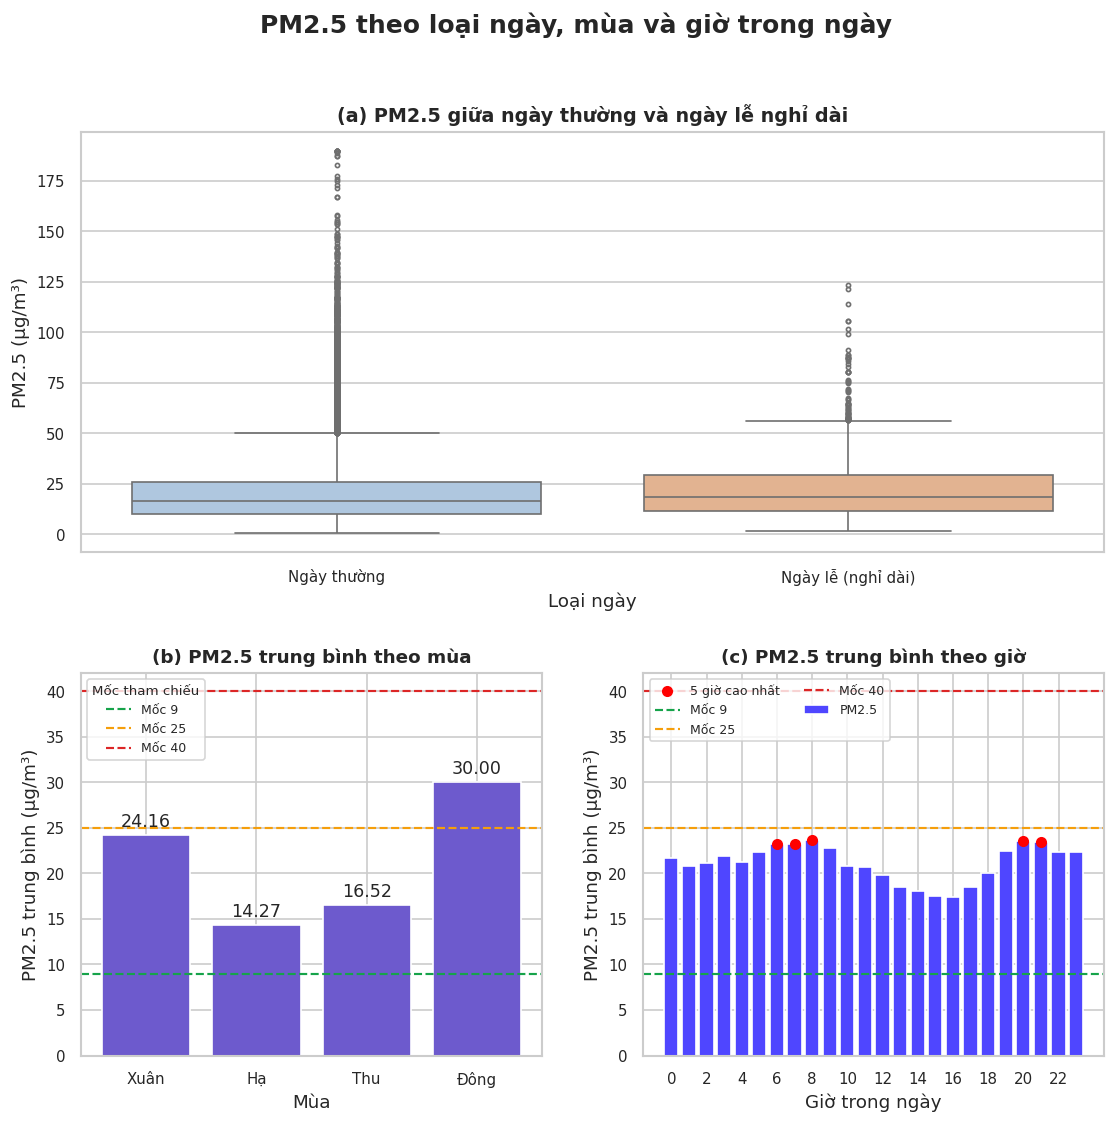

,Ngày thường,Ngày lễ (nghỉ dài)
Trung vị PM2.5,16.5,18.64


In [6]:
# Chuẩn bị dữ liệu dùng chung
time_slice_df = df_clean[["Local Time", "PM25", "IsHoliday"]].dropna().copy()
is_holiday = time_slice_df["IsHoliday"].astype(str).str.lower().eq("true")
time_slice_df["Loại ngày"] = np.where(is_holiday, "Ngày lễ (nghỉ dài)", "Ngày thường")
time_slice_df["Giờ"] = time_slice_df["Local Time"].dt.hour

month_to_season = {
    1: "Đông", 2: "Xuân", 3: "Xuân", 4: "Xuân",
    5: "Hạ", 6: "Hạ", 7: "Hạ",
    8: "Thu", 9: "Thu", 10: "Thu",
    11: "Đông", 12: "Đông"
}
season_order = ["Xuân", "Hạ", "Thu", "Đông"]
time_slice_df["Mùa"] = time_slice_df["Local Time"].dt.month.map(month_to_season)
seasonal_pm25 = time_slice_df.groupby("Mùa", observed=True)["PM25"].mean().reindex(season_order)
hourly_pm25 = time_slice_df.groupby("Giờ")["PM25"].mean().reindex(range(24))
highest_hours = hourly_pm25.nlargest(5)
reference_levels = [(9, "#16a34a", "Mốc 9"), (25, "#f59e0b", "Mốc 25"), (40, "#dc2626", "Mốc 40")]

fig = plt.figure(figsize=(11, 10))
grid = fig.add_gridspec(2, 2, height_ratios=[1.1, 1], hspace=0.30, wspace=0.22)
ax_holiday = fig.add_subplot(grid[0, :])
ax_season = fig.add_subplot(grid[1, 0])
ax_hour = fig.add_subplot(grid[1, 1])

# (a) Ngày thường và ngày lễ
holiday_order = ["Ngày thường", "Ngày lễ (nghỉ dài)"]
sns.boxplot(
    data=time_slice_df, x="Loại ngày", y="PM25", order=holiday_order,
    hue="Loại ngày", palette=["#a7c7e7", "#efb184"], legend=False,
    linewidth=1, fliersize=2.5, ax=ax_holiday
)
ax_holiday.set_title("(a) PM2.5 giữa ngày thường và ngày lễ nghỉ dài", fontsize=11.5)
ax_holiday.set_xlabel("Loại ngày")
ax_holiday.set_ylabel("PM2.5 (µg/m³)")

# (b) Trung bình theo mùa
season_bars = ax_season.bar(seasonal_pm25.index, seasonal_pm25.values, color="#6d5acd")
ax_season.bar_label(season_bars, fmt="%.2f", padding=3)
for level, color, label in reference_levels:
    ax_season.axhline(level, color=color, linestyle="--", linewidth=1.3, label=label)
ax_season.set_title("(b) PM2.5 trung bình theo mùa", fontsize=11)
ax_season.set_xlabel("Mùa")
ax_season.set_ylabel("PM2.5 trung bình (µg/m³)")
ax_season.legend(title="Mốc tham chiếu", loc="upper left", fontsize=7.5, title_fontsize=8)

# (c) Trung bình theo giờ trong ngày
hour_bars = ax_hour.bar(hourly_pm25.index, hourly_pm25.values, color="#4f46ff", label="PM2.5")
ax_hour.scatter(highest_hours.index, highest_hours.values, color="red", s=32, zorder=3, label="5 giờ cao nhất")
for level, color, label in reference_levels:
    ax_hour.axhline(level, color=color, linestyle="--", linewidth=1.3, label=label)
ax_hour.set_xticks(range(0, 24, 2))
ax_hour.set_title("(c) PM2.5 trung bình theo giờ", fontsize=11)
ax_hour.set_xlabel("Giờ trong ngày")
ax_hour.set_ylabel("PM2.5 trung bình (µg/m³)")
ax_hour.legend(loc="upper left", fontsize=7.5, ncol=2, frameon=True)

fig.suptitle("PM2.5 theo loại ngày, mùa và giờ trong ngày", fontsize=15, fontweight="bold", y=0.98)
save_report_figure(fig, "hinh_4_5_pm25_theo_loai_ngay_mua_gio.png")
plt.show()

display(pd.DataFrame({
    "Ngày thường": [time_slice_df.loc[~is_holiday, "PM25"].median()],
    "Ngày lễ (nghỉ dài)": [time_slice_df.loc[is_holiday, "PM25"].median()]
}, index=["Trung vị PM2.5"]).round(2))

## 5. Mối liên hệ giữa thời tiết và PM2.5

Biểu đồ cột thể hiện chiều và độ mạnh tương đối của mối liên hệ. Biểu đồ phân tán bên cạnh minh họa yếu tố có tương quan tuyệt đối lớn nhất với PM2.5.

Đã lưu hình: E:\Document\hoankiem-air-quality-forecasting\reports\figures\hinh_4_6_thoi_tiet_va_pm25.png


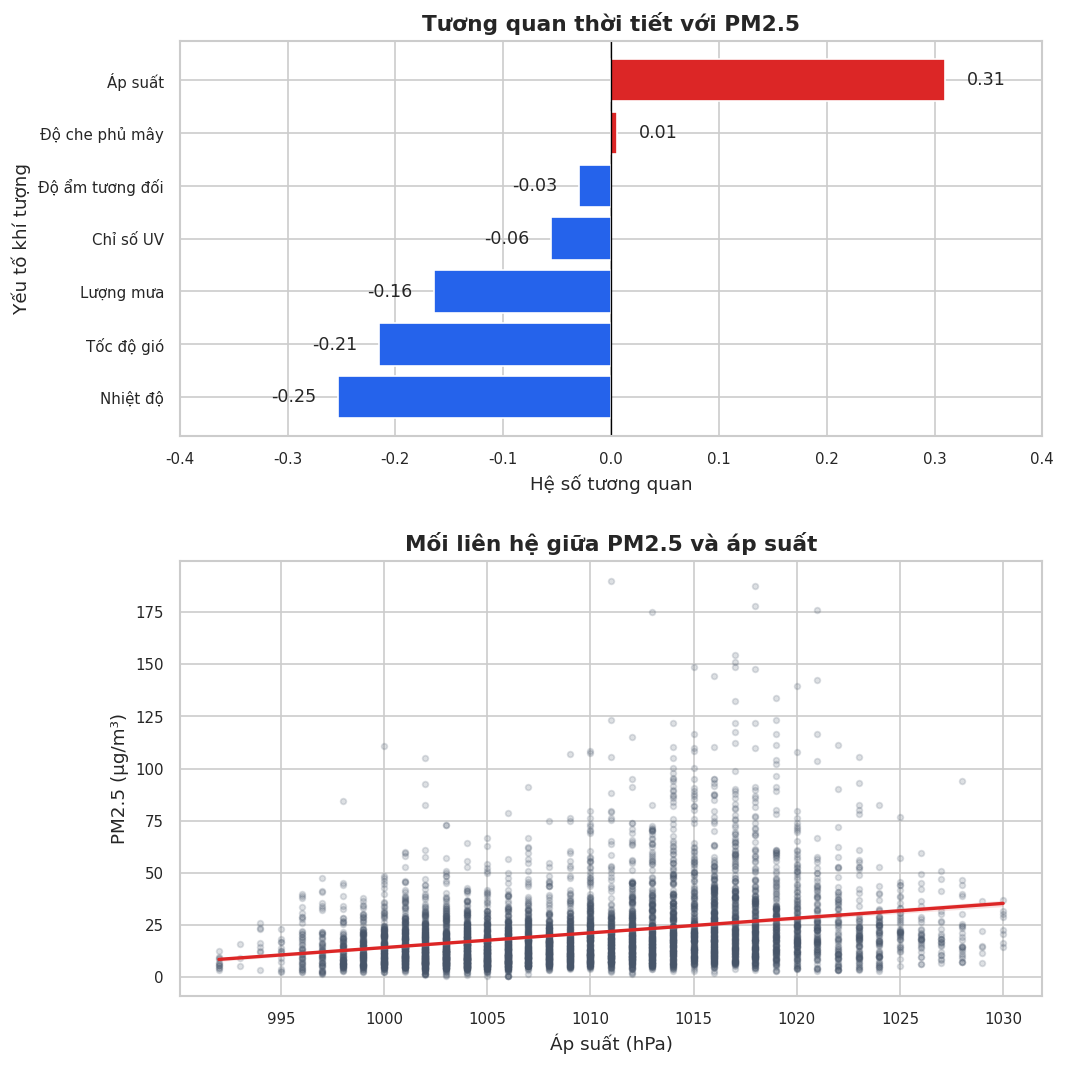

Yếu tố có |tương quan| lớn nhất: Áp suất (rho = 0.310)


In [7]:
weather_corr = df_clean[["PM25"] + weather_cols].corr(method="spearman")["PM25"].drop("PM25").sort_values()
strongest_weather = weather_corr.abs().idxmax()
detail_df = df_clean[[strongest_weather, "PM25"]].dropna()
if len(detail_df) > 6000:
    detail_df = detail_df.sample(6000, random_state=42)

fig, axes = plt.subplots(2, 1, figsize=(9, 9), gridspec_kw={"height_ratios": [1, 1.1]})
weather_labels = [display_names.get(col, col) for col in weather_corr.index]
colors = ["#dc2626" if value > 0 else "#2563eb" for value in weather_corr.values]
bars = axes[0].barh(weather_labels, weather_corr.values, color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
corr_limit = min(1.0, max(0.4, weather_corr.abs().max() + 0.08))
axes[0].set_xlim(-corr_limit, corr_limit)
axes[0].set_title("Tương quan thời tiết với PM2.5")
axes[0].set_xlabel("Hệ số tương quan")
axes[0].set_ylabel("Yếu tố khí tượng")
for bar, value in zip(bars, weather_corr.values):
    offset = 0.02 if value >= 0 else -0.02
    axes[0].text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center", ha="left" if value >= 0 else "right")
sns.regplot(data=detail_df, x=strongest_weather, y="PM25", ax=axes[1], scatter_kws={"alpha": 0.18, "s": 12, "color": "#475569"}, line_kws={"color": "#dc2626", "linewidth": 2})
weather_name = display_names.get(strongest_weather, strongest_weather)
weather_unit = weather_units.get(strongest_weather, "")
unit_suffix = f" ({weather_unit})" if weather_unit else ""
axes[1].set_title(f"Mối liên hệ giữa PM2.5 và {weather_name.lower()}")
axes[1].set_xlabel(f"{weather_name}{unit_suffix}")
axes[1].set_ylabel("PM2.5 (µg/m³)")
fig.tight_layout(h_pad=2.2)
save_report_figure(fig, "hinh_4_6_thoi_tiet_va_pm25.png")
plt.show()
print(f"Yếu tố có |tương quan| lớn nhất: {weather_name} (rho = {weather_corr[strongest_weather]:.3f})")